## Publication figures (correlation analyses)

Key figures are saved to `figures/` at 300 DPI for publication.

## Correlation with LOF and classification using highly correlated metabolites

1. Compute correlation of each metabolite (Z-scores) with LOF.
2. Select metabolites with high |correlation| with LOF.
3. Run LOF prediction using only those features.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from metabolites_classifier import MetaboliteConditionClassifier

df = pd.read_csv("data1.csv")
df_ml = df.dropna(subset=["LOF"]).copy()
df_ml["Condition_mapped"] = df_ml["LOF"].astype(int).astype(str)
z_cols = [c for c in df_ml.columns if c.startswith("Z") and len(c) > 1]
feature_cols = (["ageatcollection"] if "ageatcollection" in df_ml.columns else []) + z_cols
feature_cols = [c for c in feature_cols if c in df_ml.columns]
X = df_ml[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(df_ml[feature_cols].apply(pd.to_numeric, errors="coerce").median())
y = df_ml["LOF"].astype(int)
# Correlation of each feature with LOF
corr_with_lof = X.corrwith(y).abs().sort_values(ascending=False)
print("Correlation (absolute) with LOF:")
print(corr_with_lof.head(15))

Correlation (absolute) with LOF:
Z@3MEGLUTACONIC      0.432305
Z@3OHPROPIONIC       0.425533
Z@3ME2KETOVALERIC    0.299393
ZACETOACETICl        0.289838
Z@3OHBUT             0.288869
ZPYRUVIC             0.268532
Z@2KETOISOCAPROIC    0.250674
Z@3OHIVAl            0.218244
Z@2MECITRIC          0.200985
Z@3OH2MEBUT          0.183326
ZSUCCINIC            0.153259
ZLACTIC              0.147233
Z@2OHBUT             0.122231
Z@2KETOBUTl          0.116950
ZCISACONITIC         0.095851
dtype: float64


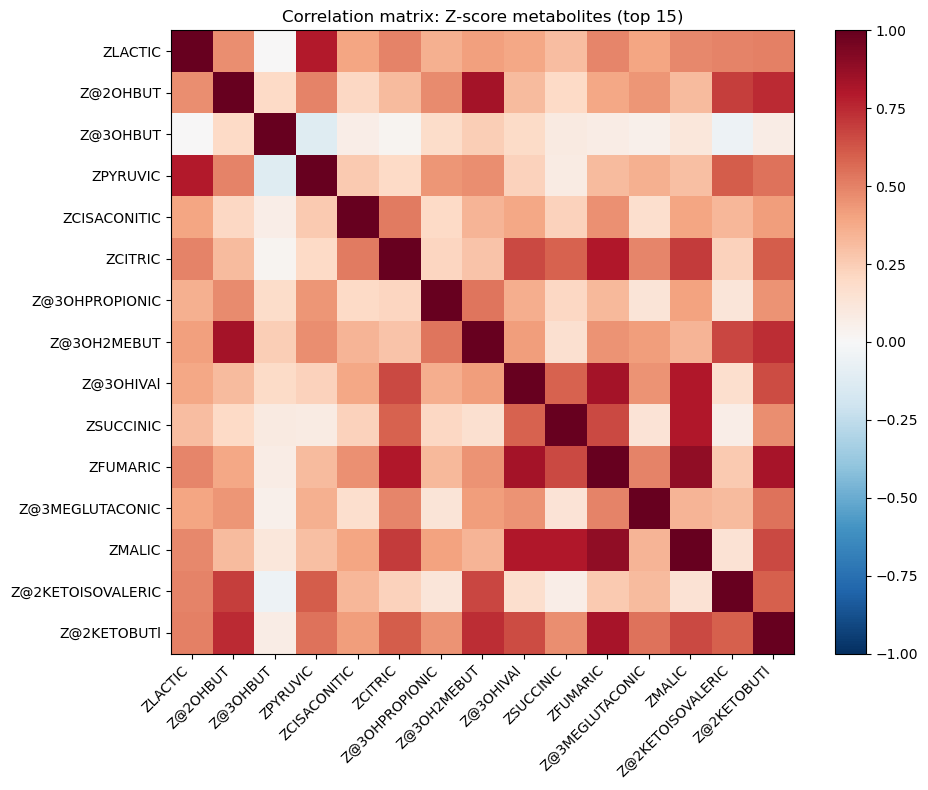

In [27]:
# Heatmap: correlation matrix of Z-score metabolites (top 15 for readability)
import os
os.makedirs("figures", exist_ok=True)
corr_cols_hm = [c for c in feature_cols if c.startswith("Z")][:15]
corr_matrix_all = X[corr_cols_hm].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix_all, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_matrix_all.columns)))
ax.set_xticklabels(corr_matrix_all.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix_all.columns)))
ax.set_yticklabels(corr_matrix_all.columns)
ax.set_title("Correlation matrix: Z-score metabolites (top 15)")
plt.tight_layout()
fig.savefig("figures/corr_zscore_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

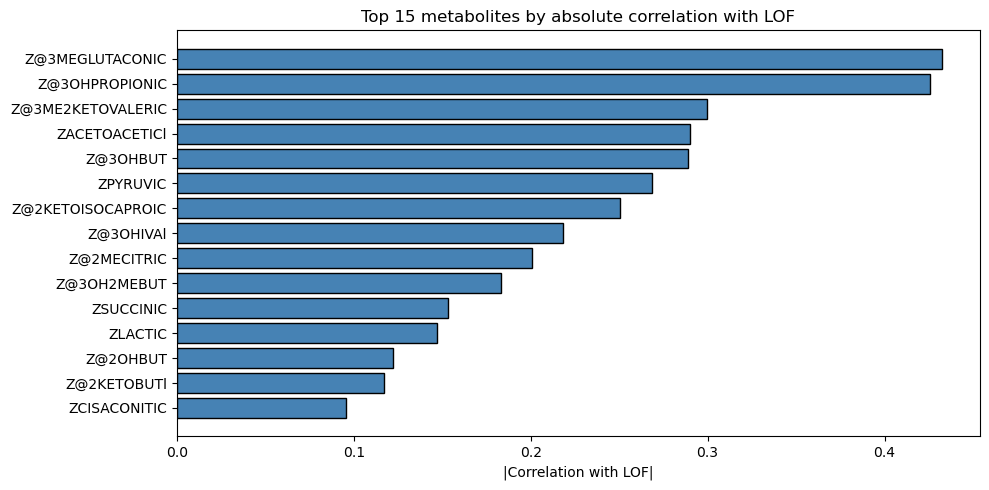

In [28]:
# Bar chart: correlation with LOF (top 15)
top_n = 15
top_corr = corr_with_lof.head(top_n)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(top_corr)), top_corr.values, color="steelblue", edgecolor="black")
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index)
ax.set_xlabel("|Correlation with LOF|")
ax.set_title("Top {} metabolites by absolute correlation with LOF".format(top_n))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

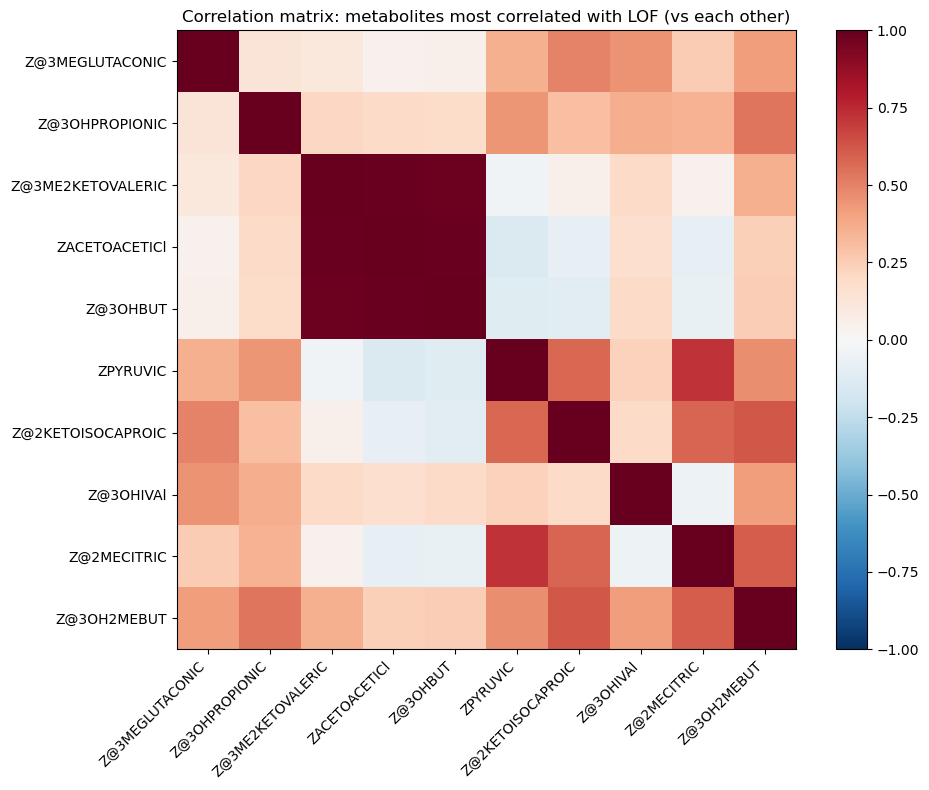

In [29]:
# Heatmap: highly correlated (with LOF) metabolites vs each other
corr_high = X[high_corr_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_high, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_high.columns)))
ax.set_xticklabels(corr_high.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_high.columns)))
ax.set_yticklabels(corr_high.columns)
ax.set_title("Correlation matrix: metabolites most correlated with LOF (vs each other)")
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/corr_lof_high_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
# Select highly correlated features: top k by |correlation with LOF|
TOP_K = 10
high_corr_cols = corr_with_lof.head(TOP_K).index.tolist()
print("Selected {} highly correlated features:".format(len(high_corr_cols)))
print(high_corr_cols)

Selected 10 highly correlated features:
['Z@3MEGLUTACONIC', 'Z@3OHPROPIONIC', 'Z@3ME2KETOVALERIC', 'ZACETOACETICl', 'Z@3OHBUT', 'ZPYRUVIC', 'Z@2KETOISOCAPROIC', 'Z@3OHIVAl', 'Z@2MECITRIC', 'Z@3OH2MEBUT']


In [31]:
# Run LOF prediction using only highly correlated features (pass list as feature_set)
clf_corr = MetaboliteConditionClassifier(df_ml, feature_set=high_corr_cols, test_size=0.25, random_state=42)
clf_corr.prepare_data()
results_corr = clf_corr.run_models(include_xgb=True, verbose=True)
results_corr_df = pd.DataFrame(results_corr)
print("\nSummary (highly correlated features only):")
print(results_corr_df[["Model", "CV Accuracy (mean)", "CV std", "Test Accuracy"]])


--- Logistic Regression ---
CV accuracy: 0.747 (+/- 0.096)
Test accuracy: 0.700
              precision    recall  f1-score   support

           0       0.75      0.86      0.80         7
           1       0.50      0.33      0.40         3

    accuracy                           0.70        10
   macro avg       0.62      0.60      0.60        10
weighted avg       0.68      0.70      0.68        10


--- Random Forest ---
CV accuracy: 0.793 (+/- 0.124)
Test accuracy: 0.800
              precision    recall  f1-score   support

           0       0.78      1.00      0.88         7
           1       1.00      0.33      0.50         3

    accuracy                           0.80        10
   macro avg       0.89      0.67      0.69        10
weighted avg       0.84      0.80      0.76        10


--- SVM (RBF) ---
CV accuracy: 0.753 (+/- 0.072)
Test accuracy: 0.700
              precision    recall  f1-score   support

           0       0.75      0.86      0.80         7
          

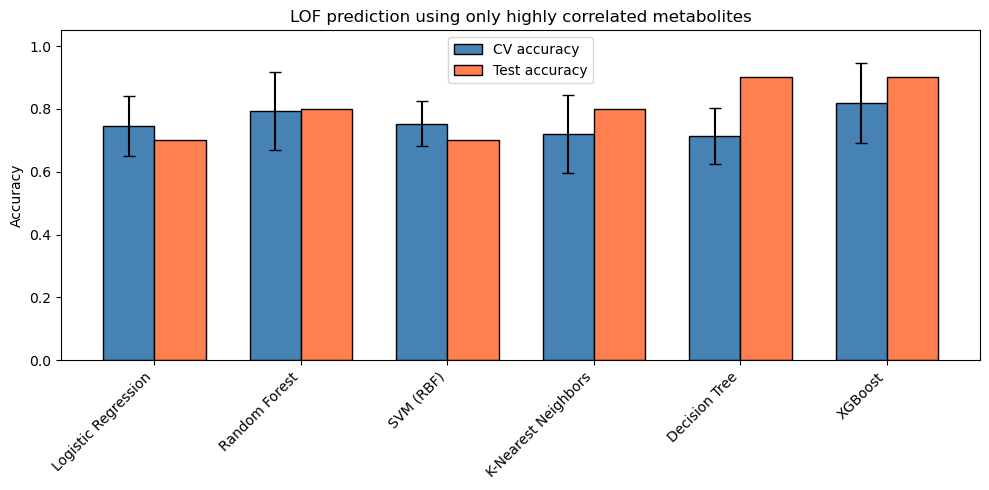

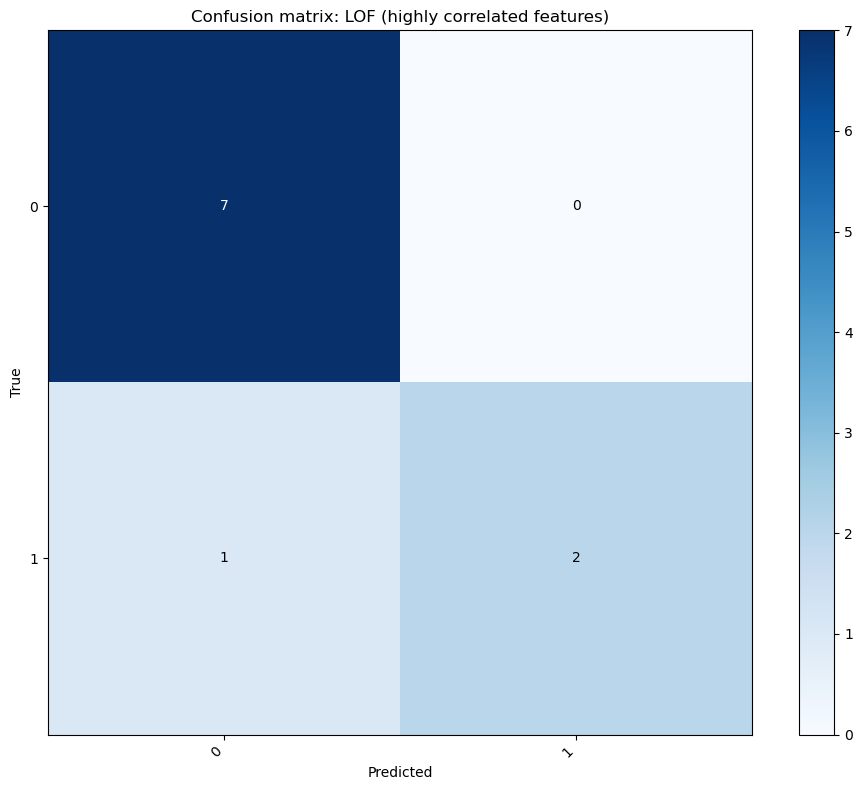

In [32]:
# Model comparison (highly correlated features only)
x = np.arange(len(results_corr_df))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, results_corr_df["CV Accuracy (mean)"], width, yerr=results_corr_df["CV std"], label="CV accuracy", capsize=4, color="steelblue", edgecolor="black")
ax.bar(x + width/2, results_corr_df["Test Accuracy"], width, label="Test accuracy", color="coral", edgecolor="black")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(results_corr_df["Model"], rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 1.05)
ax.set_title("LOF prediction using only highly correlated metabolites")
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/corr_lof_high_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
clf_corr.confusion_matrix_plot("XGBoost")
plt.title("Confusion matrix: LOF (highly correlated features)")
plt.tight_layout()
plt.gcf().savefig("figures/corr_lof_high_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Feature selection: metabolites most correlated with each other

Select features that are most correlated with other metabolites (inter-correlation). Then run LOF prediction using only this subset.

In [33]:
# Metabolite–metabolite correlation matrix; rank by mean |correlation| with other features
corr_feat = X[feature_cols].corr()
# For each feature: mean absolute correlation with all other features (exclude self)
n = len(corr_feat)
mean_abs_corr = (corr_feat.abs().sum(axis=1) - 1) / (n - 1)
mean_abs_corr = mean_abs_corr.sort_values(ascending=False)
TOP_K_INTER = 10
inter_corr_cols = mean_abs_corr.head(TOP_K_INTER).index.tolist()
print("Top {} metabolites by mean |correlation| with other metabolites:".format(TOP_K_INTER))
print(inter_corr_cols)

Top 10 metabolites by mean |correlation| with other metabolites:
['Z@2KETOBUTl', 'Z@2KETOGLUTARIC', 'ZFUMARIC', 'Z@3OH2MEBUT', 'ZMALIC', 'Z@2OHBUT', 'Z@3OHIVAl', 'ZLACTIC', 'ZCITRIC', 'ZPYRUVIC']


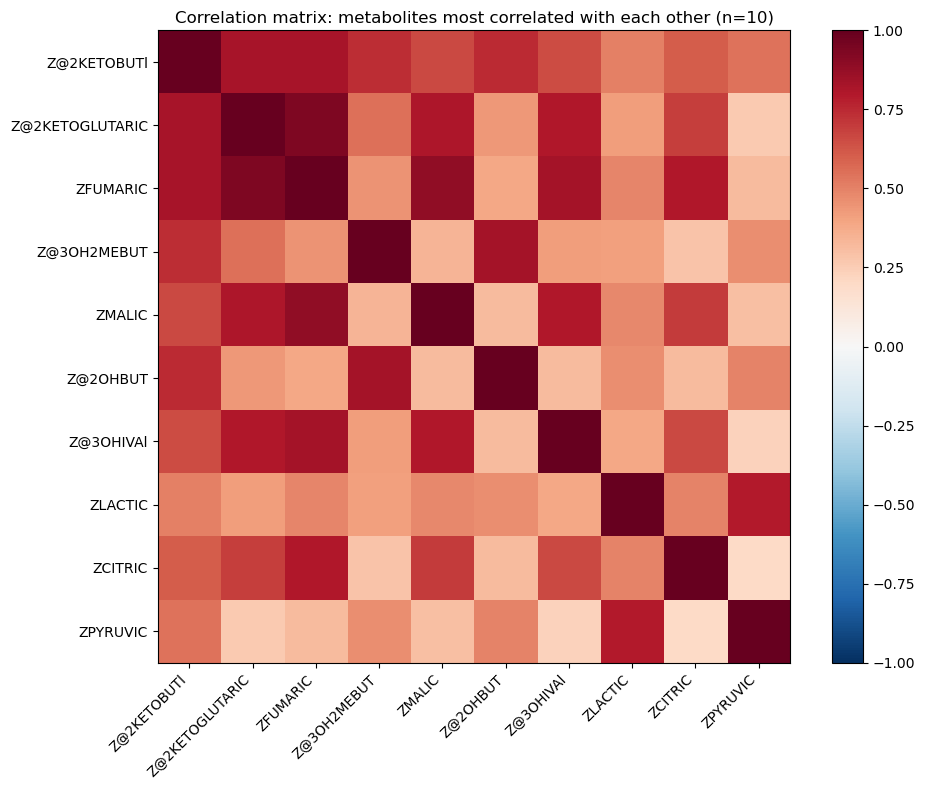

In [34]:
# Heatmap: metabolites most correlated with each other (subset)
corr_inter = X[inter_corr_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_inter, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_inter.columns)))
ax.set_xticklabels(corr_inter.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_inter.columns)))
ax.set_yticklabels(corr_inter.columns)
ax.set_title("Correlation matrix: metabolites most correlated with each other (n={})".format(len(inter_corr_cols)))
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/corr_inter_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

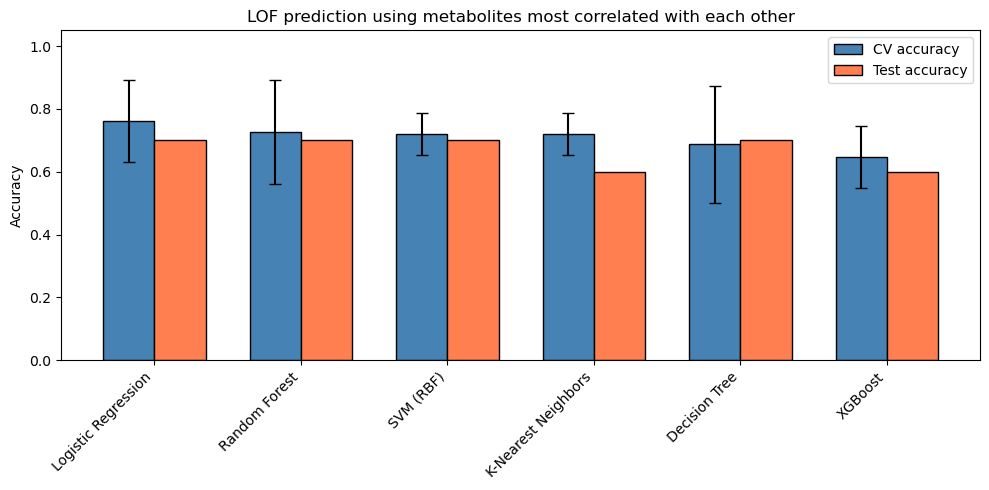

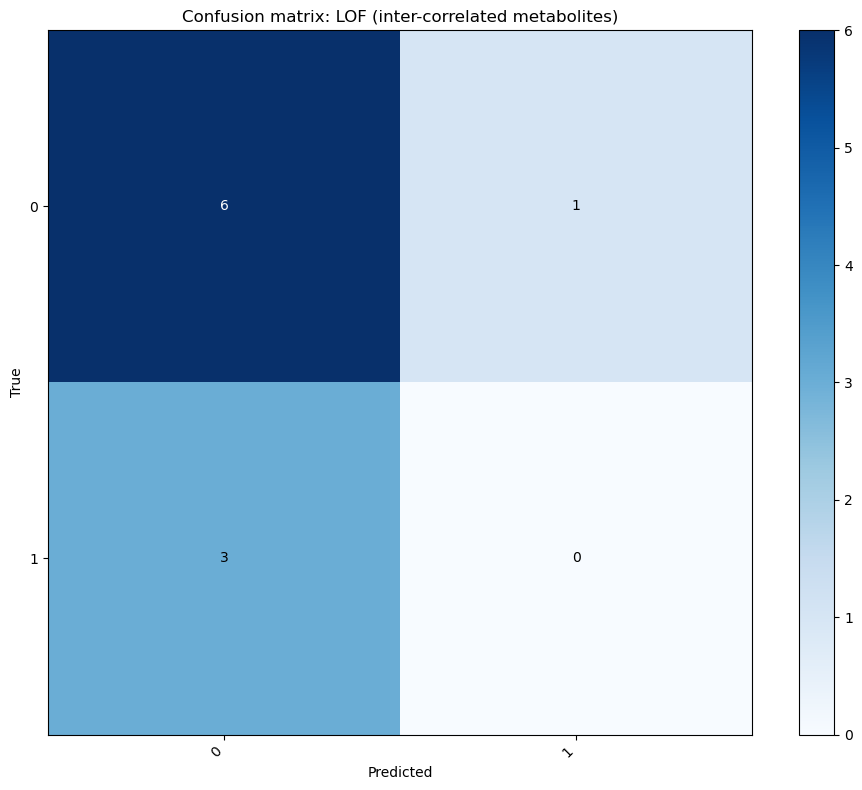

In [35]:
# Model comparison and confusion matrix (inter-correlated features)
try:
    len(results_inter_df)
except NameError:
    clf_inter = MetaboliteConditionClassifier(df_ml, feature_set=inter_corr_cols, test_size=0.25, random_state=42)
    clf_inter.prepare_data()
    results_inter = clf_inter.run_models(include_xgb=True, verbose=False)
    results_inter_df = pd.DataFrame(results_inter)

x = np.arange(len(results_inter_df))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, results_inter_df["CV Accuracy (mean)"], width, yerr=results_inter_df["CV std"], label="CV accuracy", capsize=4, color="steelblue", edgecolor="black")
ax.bar(x + width/2, results_inter_df["Test Accuracy"], width, label="Test accuracy", color="coral", edgecolor="black")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(results_inter_df["Model"], rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 1.05)
ax.set_title("LOF prediction using metabolites most correlated with each other")
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/corr_inter_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
clf_inter.confusion_matrix_plot("XGBoost")
plt.title("Confusion matrix: LOF (inter-correlated metabolites)")
plt.tight_layout()
plt.gcf().savefig("figures/corr_inter_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()